# QUIZ 2

Sumber : [Link](https://www.kaggle.com/datasets/dhrubangtalukdar/global-llm-benchmark-dataset-20242026)

A comprehensive comparison dataset of leading Large Language Models (LLMs) including GPT, Claude, Gemini, Llama, Mistral, DeepSeek, Qwen and more.

This dataset aggregates benchmark performance, context window size, API pricing, and model metadata into a structured format for analysis and research.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
data_analysis = pd.read_csv(r"C:\Users\Mareko\Downloads\Persentase Rumah Tangga Menurut Provinsi dan Fasilitas Tempat Buang Air Besar, 2021.csv", sep=",", skiprows=[1,3], header=1)

df = pd.DataFrame(data_analysis)
df.drop(columns=['Jumlah'], inplace=True)
print(df.head(21))

# Ganti '-' dengan 0 dan konversi ke numerik jika memungkinkan
df = df.replace("-", 0)
for col in df.columns[1:7]:
    df[col] = pd.to_numeric(df[col], errors='coerce')



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Mareko\\Downloads\\Persentase Rumah Tangga Menurut Provinsi dan Fasilitas Tempat Buang Air Besar, 2021.csv'

## Barchart dan Pie Chart

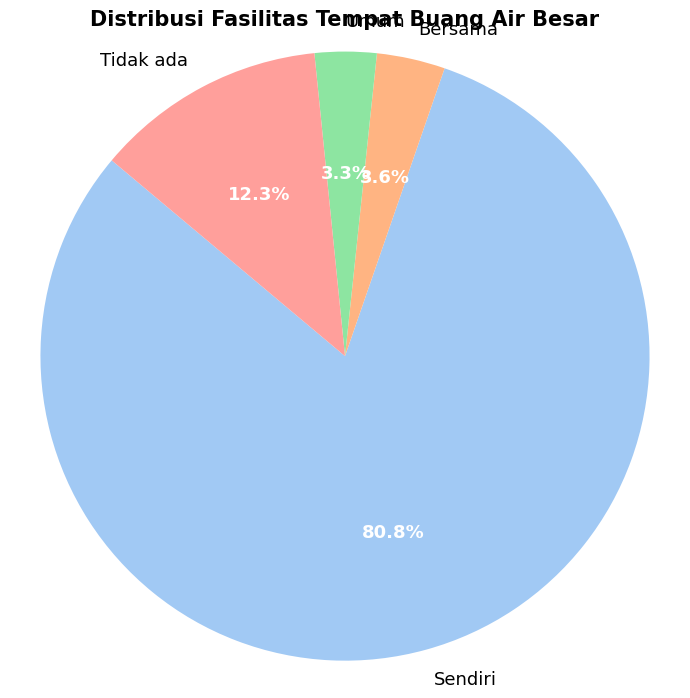

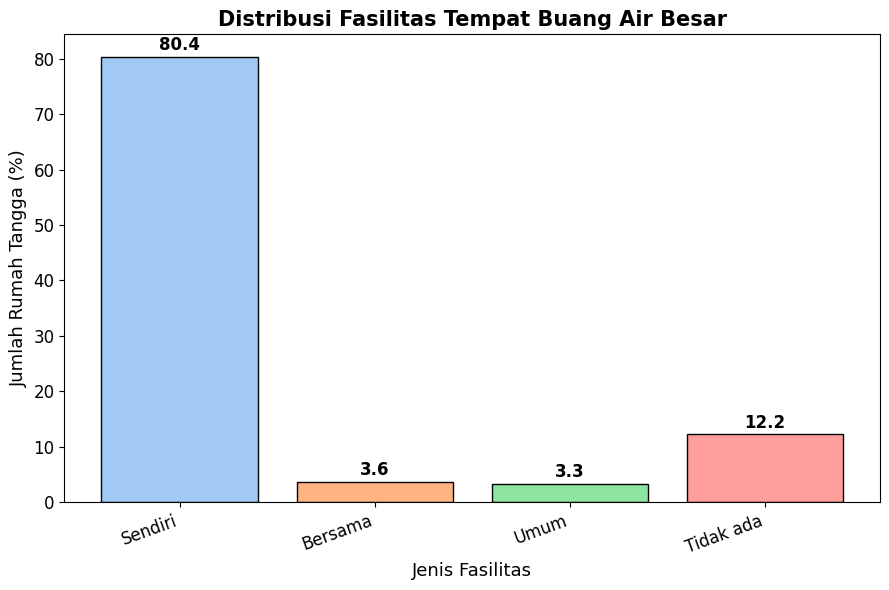

In [ ]:
# Pilih kolom dan nilai untuk pie chart tanpa 'Jumlah'
Labels = [col for col in df.columns[1:] if col != 'Jumlah']
Values = df.loc[:, Labels].iloc[0].astype(float)

# Pie chart yang lebih rapi
colors = sns.color_palette('pastel')[0:len(Labels)]
plt.figure(figsize=(7,7))
wedges, texts, autotexts = plt.pie(Values, labels=Labels, autopct='%1.1f%%', startangle=140, colors=colors, textprops={'fontsize': 12})
plt.setp(autotexts, size=13, weight="bold", color="white")
plt.setp(texts, size=13)
plt.axis('equal')
plt.title('Distribusi Fasilitas Tempat Buang Air Besar', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

# Bar chart yang lebih rapi dan informatif
plt.figure(figsize=(9,6))
bar_colors = sns.color_palette('pastel')[0:len(Labels)]
bars = plt.bar(Labels, Values, color=bar_colors, edgecolor='black')
plt.xlabel('Jenis Fasilitas', fontsize=13)
plt.ylabel('Jumlah Rumah Tangga (%)', fontsize=13)
plt.title('Distribusi Fasilitas Tempat Buang Air Besar', fontsize=15, weight='bold')
plt.xticks(rotation=20, ha='right', fontsize=12)
plt.yticks(fontsize=12)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}', ha='center', va='bottom', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

## Histogram dan Scatter PLot

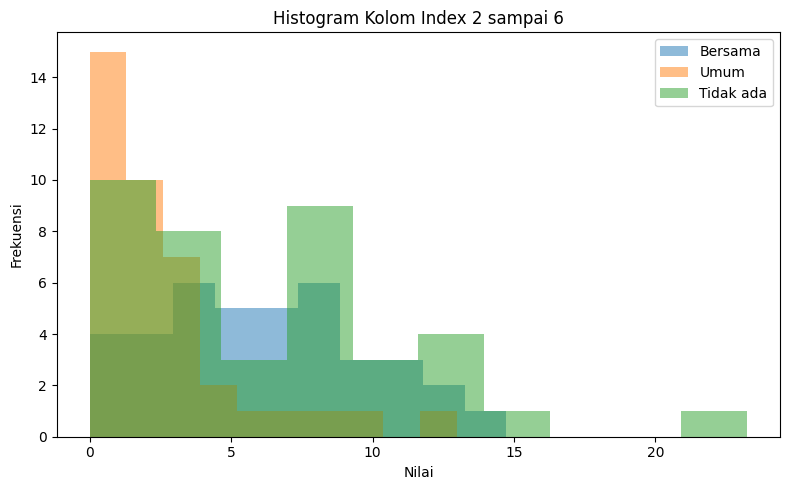

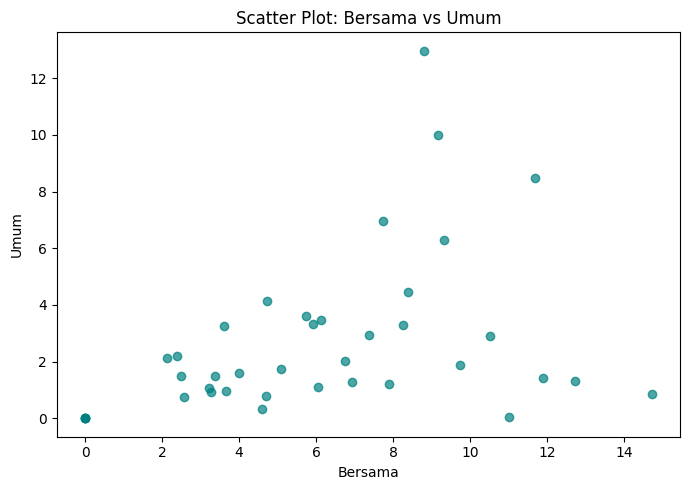

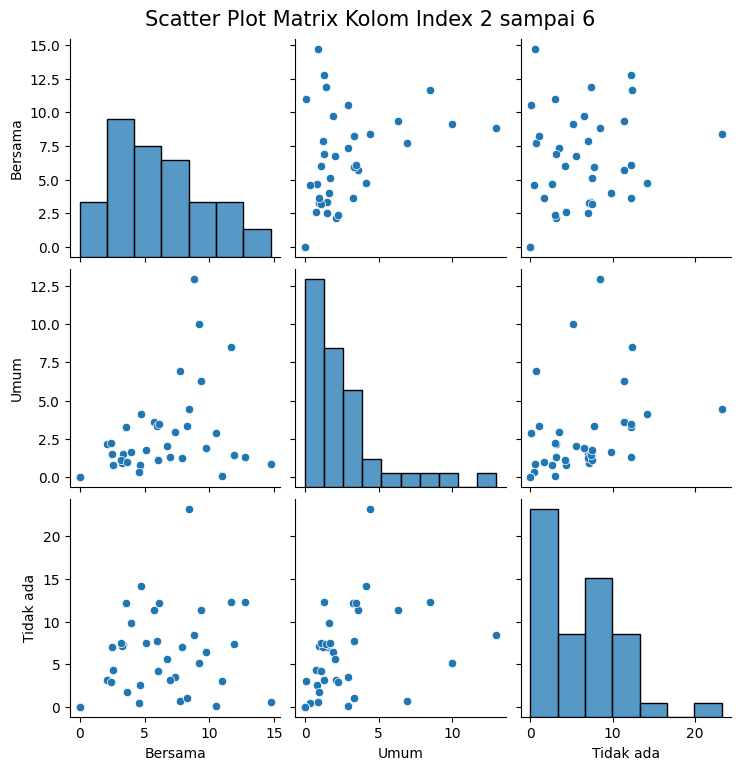

In [ ]:
# Histogram sederhana untuk kolom index 2 sampai 6 tanpa 'Jumlah'
hist_cols = [col for col in df.columns[2:] if col != 'Jumlah']
plt.figure(figsize=(8,5))
for col in hist_cols:
    plt.hist(df[col].dropna().astype(float), bins=10, alpha=0.5, label=col)
plt.xlabel('Nilai')
plt.ylabel('Frekuensi')
plt.title('Histogram Kolom Index 2 sampai 6')
plt.legend()
plt.tight_layout()
plt.show()

# Scatter plot antar kolom index 2 dan 3 (contoh) tanpa 'Jumlah'
scatter_x = hist_cols[0] if len(hist_cols) > 1 else df.columns[2]
scatter_y = hist_cols[1] if len(hist_cols) > 1 else df.columns[3]
plt.figure(figsize=(7,5))
plt.scatter(df[scatter_x].astype(float), df[scatter_y].astype(float), color='teal', alpha=0.7)
plt.xlabel(scatter_x)
plt.ylabel(scatter_y)
plt.title(f'Scatter Plot: {scatter_x} vs {scatter_y}')
plt.tight_layout()
plt.show()

# Scatter plot matrix untuk kolom index 2 sampai 6 tanpa 'Jumlah'
if len(hist_cols) > 1:
    sns.pairplot(df[hist_cols].astype(float))
    plt.suptitle('Scatter Plot Matrix Kolom Index 2 sampai 6', y=1.02, fontsize=15)
    plt.show()